In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [8]:
df = pd.read_excel(r'C:\Users\LHY\Desktop\吴志祥老师的大数据\数据分析.xlsx')


print("=== 数据形状 ===")
print(df.shape)
print("\n=== 前5行 ===")
print(df.head())

=== 数据形状 ===
(101766, 15)

=== 前5行 ===
   种族  性别  年龄  住院天数  实验室检查次数  医疗操作次数  使用药物数量  门诊就诊次数  急诊就诊次数  住院次数  最高血清血糖  \
0   0   0   1     1       41       0       1       0       0     0       0   
1   0   0   2     3       59       0      18       0       0     0       0   
2   1   0   3     2       11       5      13       2       0     1       0   
3   0   1   4     2       44       1      16       0       0     0       0   
4   0   1   5     1       51       0       8       0       0     0       0   

   糖化血红蛋白结果  诊断总数  再次入院情况  has_complication  
0         0     1       0                 1  
1         0     9       1                 0  
2         0     6       0                 0  
3         0     7       0                 1  
4         0     5       0                 0  


In [9]:
# 查看数据类型、非空值数量
print("=== 数据基本信息 ===")
print(df.info())

# 统计每列缺失值数量
print("\n=== 缺失值统计 ===")
print(df.isnull().sum())

=== 数据基本信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   种族                101766 non-null  int64
 1   性别                101766 non-null  int64
 2   年龄                101766 non-null  int64
 3   住院天数              101766 non-null  int64
 4   实验室检查次数           101766 non-null  int64
 5   医疗操作次数            101766 non-null  int64
 6   使用药物数量            101766 non-null  int64
 7   门诊就诊次数            101766 non-null  int64
 8   急诊就诊次数            101766 non-null  int64
 9   住院次数              101766 non-null  int64
 10  最高血清血糖            101766 non-null  int64
 11  糖化血红蛋白结果          101766 non-null  int64
 12  诊断总数              101766 non-null  int64
 13  再次入院情况            101766 non-null  int64
 14  has_complication  101766 non-null  int64
dtypes: int64(15)
memory usage: 11.6 MB
None

=== 缺失值统计 ===
种族                  0
性别        

In [20]:
# 分离数值型和分类型字段
num_cols = ['住院天数', '实验室检查次数', '医疗操作次数', '使用药物数量', 
            '门诊就诊次数', '急诊就诊次数', '住院次数', '最高血清血糖', 
            '糖化血红蛋白结果', '诊断总数']
cat_cols = ['种族', '性别', '年龄', '再次入院情况', 'has_complication']

# 数值变量描述性统计
print("=== 数值变量描述性统计 ===")
print(df[num_cols].describe().round(2))

=== 数值变量描述性统计 ===
            住院天数    实验室检查次数     医疗操作次数     使用药物数量     门诊就诊次数     急诊就诊次数  \
count  101766.00  101766.00  101766.00  101766.00  101766.00  101766.00   
mean        4.40      43.10       1.34      16.02       0.37       0.20   
std         2.99      19.67       1.71       8.13       1.27       0.93   
min         1.00       1.00       0.00       1.00       0.00       0.00   
25%         2.00      31.00       0.00      10.00       0.00       0.00   
50%         4.00      44.00       1.00      15.00       0.00       0.00   
75%         6.00      57.00       2.00      20.00       0.00       0.00   
max        14.00     132.00       6.00      81.00      42.00      76.00   

            住院次数     最高血清血糖   糖化血红蛋白结果       诊断总数  
count  101766.00  101766.00  101766.00  101766.00  
mean        0.64       0.12       0.35       7.42  
std         1.26       0.53       0.83       1.93  
min         0.00       0.00       0.00       1.00  
25%         0.00       0.00       0.00       6

In [23]:
for col in cat_cols:
    print(f"\n=== {col} 分布情况 ===")
    # 仅统计有效取值，过滤掉异常值2
    valid_counts = df[df[col] != 2][col].value_counts()
    print(valid_counts)
    valid_percent = df[df[col] != 2][col].value_counts(normalize=True).map(lambda x: f"{x:.2%}")
    print(valid_percent)


=== 种族 分布情况 ===
0    76099
1    19210
4     3779
3     2037
Name: 种族, dtype: int64
0    75.25%
1    19.00%
4     3.74%
3     2.01%
Name: 种族, dtype: object

=== 性别 分布情况 ===
0    54708
1    47055
Name: 性别, dtype: int64
0    53.76%
1    46.24%
Name: 性别, dtype: object

=== 年龄 分布情况 ===
8     26068
7     22483
6     17256
9     17197
5      9685
4      3775
10     2793
3      1657
1       161
Name: 年龄, dtype: int64
8     25.79%
7     22.24%
6     17.07%
9     17.01%
5      9.58%
4      3.73%
10     2.76%
3      1.64%
1      0.16%
Name: 年龄, dtype: object

=== 再次入院情况 分布情况 ===
0    54864
1    35545
Name: 再次入院情况, dtype: int64
0    60.68%
1    39.32%
Name: 再次入院情况, dtype: object

=== has_complication 分布情况 ===
0    81053
1    20713
Name: has_complication, dtype: int64
0    79.65%
1    20.35%
Name: has_complication, dtype: object


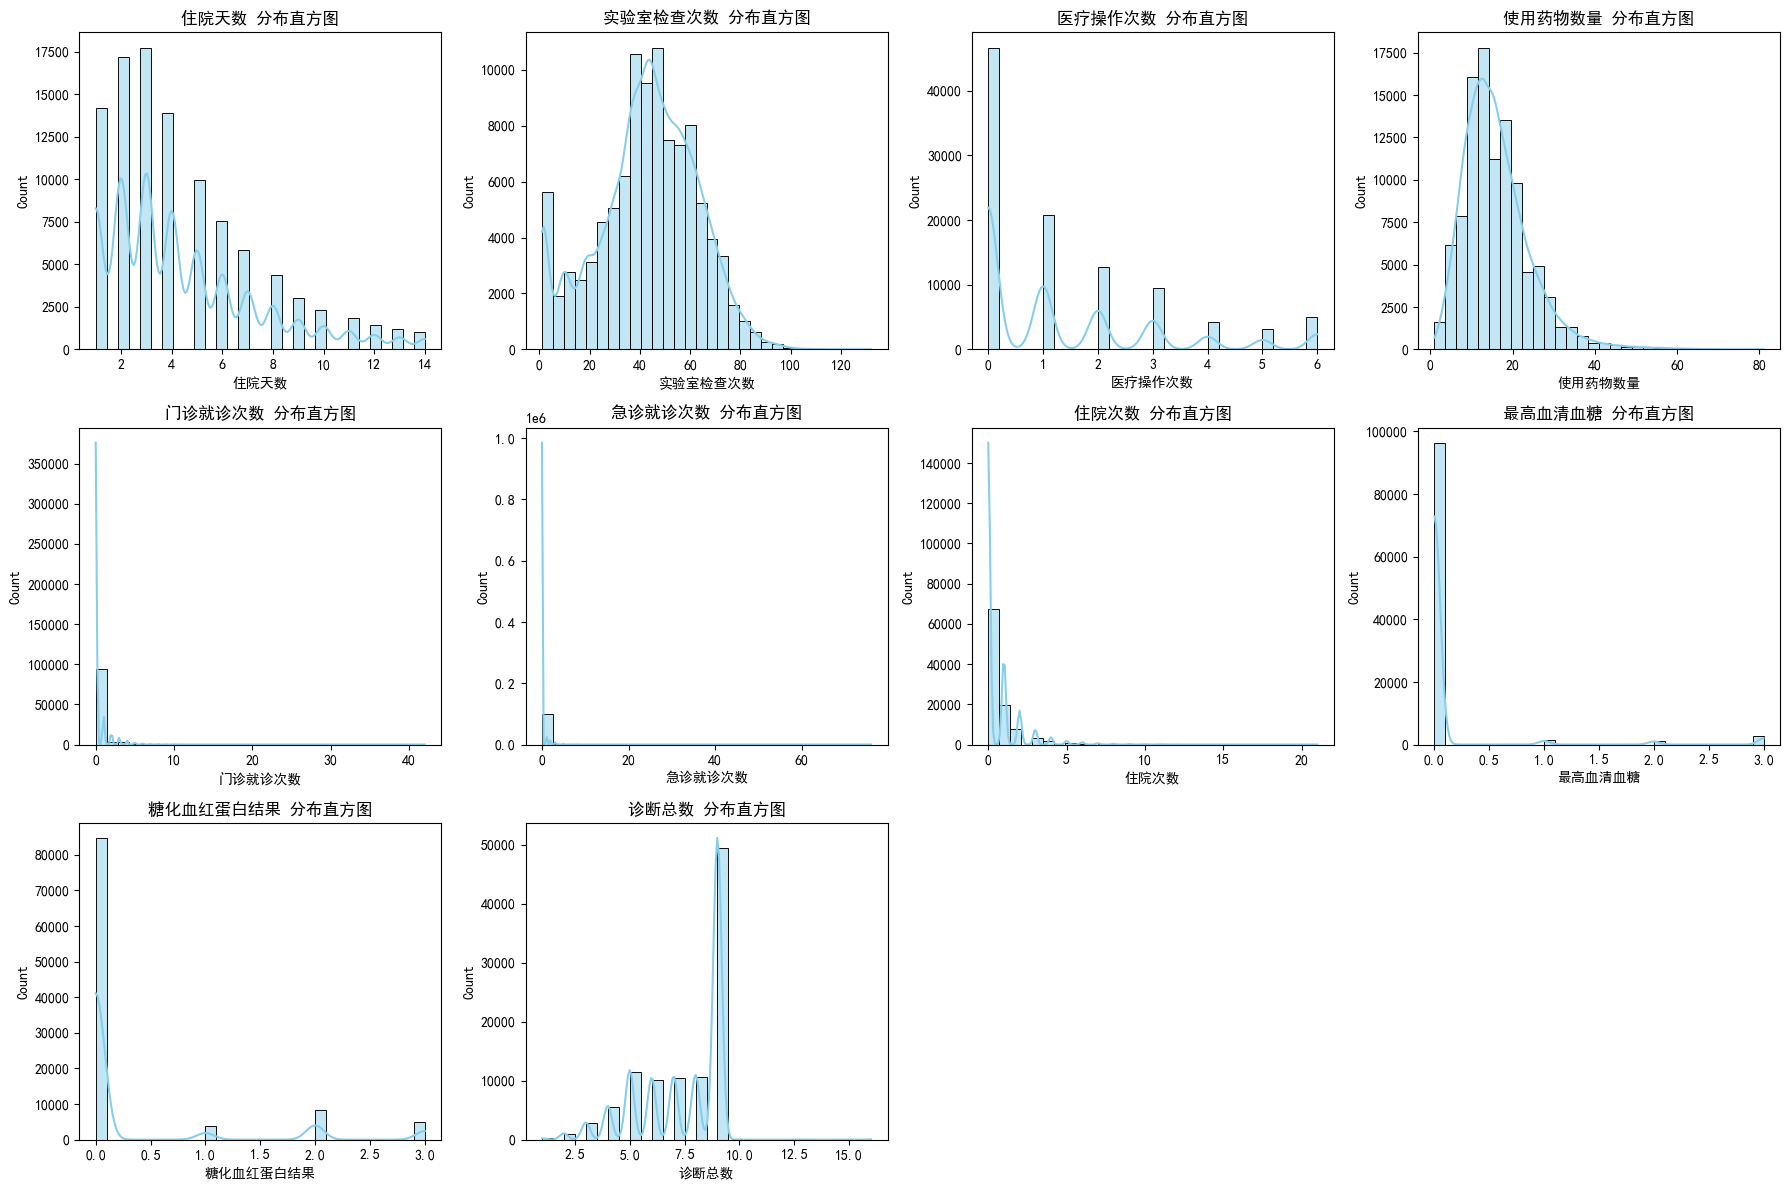

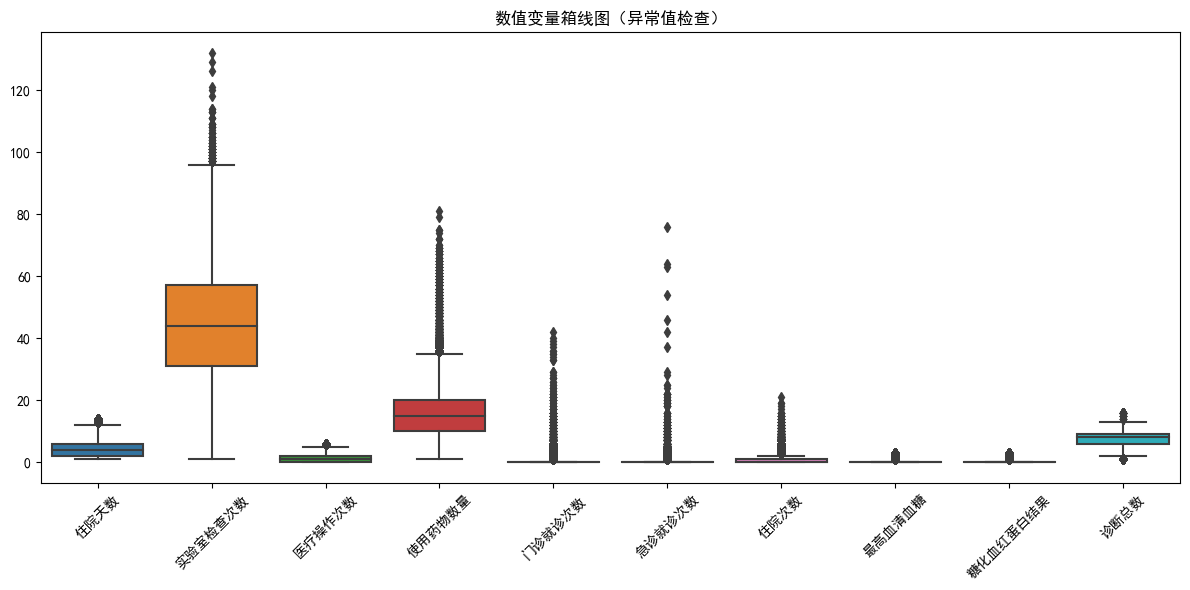

In [25]:
# 1. 数值变量分布直方图
plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} 分布直方图')
plt.tight_layout()
plt.show()

# 2. 数值变量箱线图（异常值查看）
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title('数值变量箱线图（异常值检查）')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

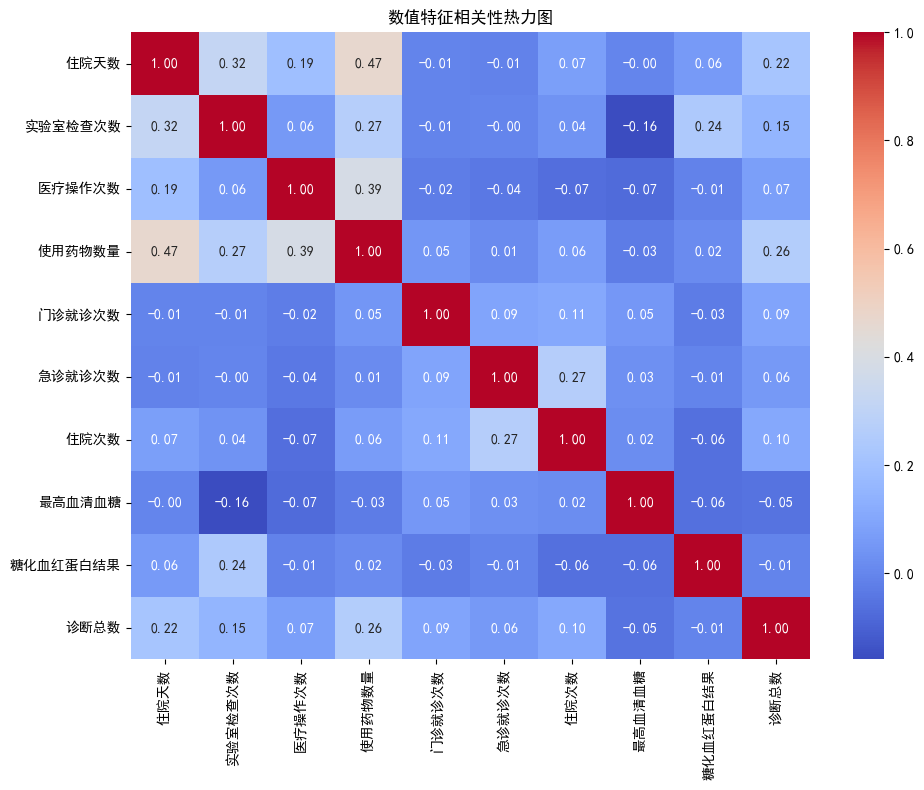

In [26]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('数值特征相关性热力图')
plt.tight_layout()
plt.show()

=== 并发症组 vs 无并发症组：数值指标对比 ===
                  住院天数        实验室检查次数        医疗操作次数        使用药物数量         \
                  mean median    mean median   mean median   mean median   
has_complication                                                           
0                 4.28    4.0   42.82   44.0   1.32    1.0  15.77   14.0   
1                 4.86    4.0   44.16   44.0   1.43    1.0  17.00   16.0   

                 门诊就诊次数        急诊就诊次数         住院次数        最高血清血糖         \
                   mean median   mean median  mean median   mean median   
has_complication                                                          
0                  0.33    0.0   0.18    0.0  0.56    0.0   0.12    0.0   
1                  0.51    0.0   0.28    0.0  0.94    0.0   0.10    0.0   

                 糖化血红蛋白结果         诊断总数         
                     mean median  mean median  
has_complication                               
0                    0.34    0.0  7.32    8.0  
1                    0

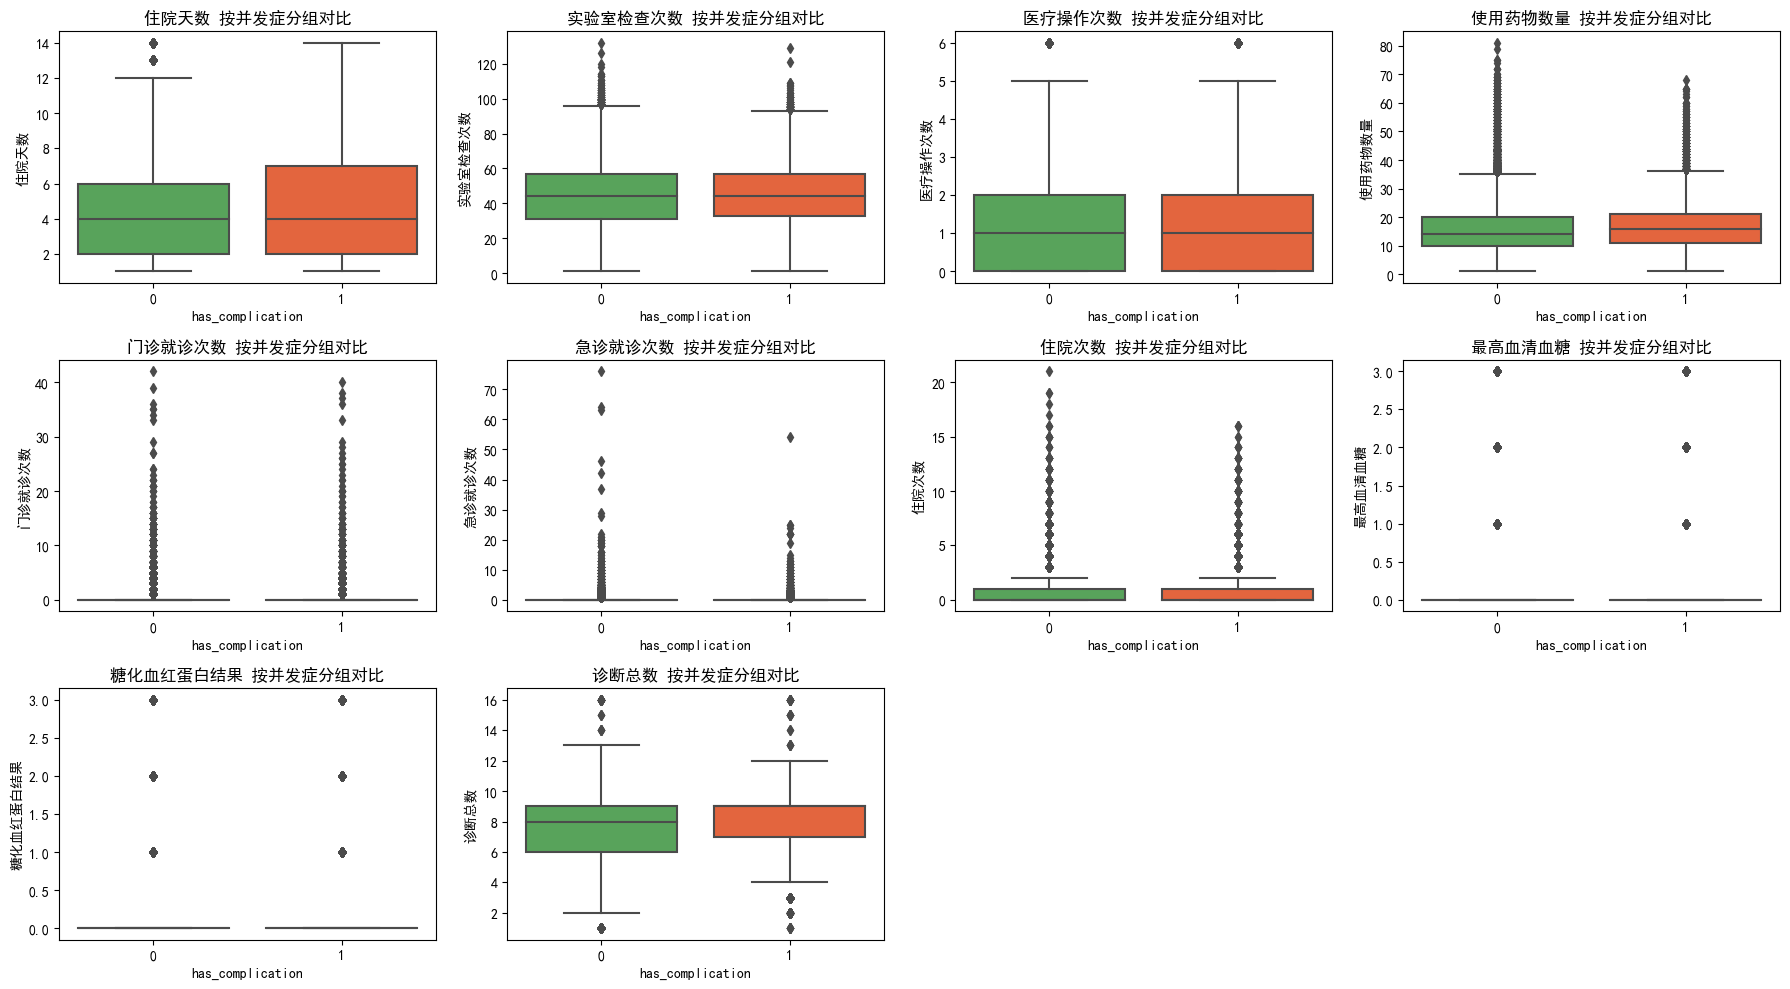


=== 种族 × 并发症 交叉表 ===

=== 性别 × 并发症 交叉表 ===

=== 年龄 × 并发症 交叉表 ===

=== 再次入院情况 × 并发症 交叉表 ===
has_complication       0       1
再次入院情况                          
0                 83.28%  16.72%
1                 76.14%  23.86%
2                 73.06%  26.94%


In [15]:
# 1. 数值变量组间均值/中位数对比
group_stats = df.groupby('has_complication')[num_cols].agg(['mean', 'median']).round(2)
print("=== 并发症组 vs 无并发症组：数值指标对比 ===")
print(group_stats)

# 2. 分组箱线图对比
plt.figure(figsize=(18, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x='has_complication', y=col, data=df, palette=['#4CAF50', '#FF5722'])
    plt.title(f'{col} 按并发症分组对比')
plt.tight_layout()
plt.show()

# 3. 分类变量与并发症的交叉分布
for col in cat_cols[:-1]:  # 排除has_complication本身
    print(f"\n=== {col} × 并发症 交叉表 ===")
cross = pd.crosstab(df[col], df['has_complication'], normalize='index')
print(cross.applymap(lambda x: f"{x:.2%}"))


=== 种族 × has_complication 交叉表 ===
    无并发症占比(%)  有并发症占比(%)
种族                      
0       81.21      18.79
1       72.97      27.03
2       80.19      19.81
3       80.27      19.73
4       81.71      18.29


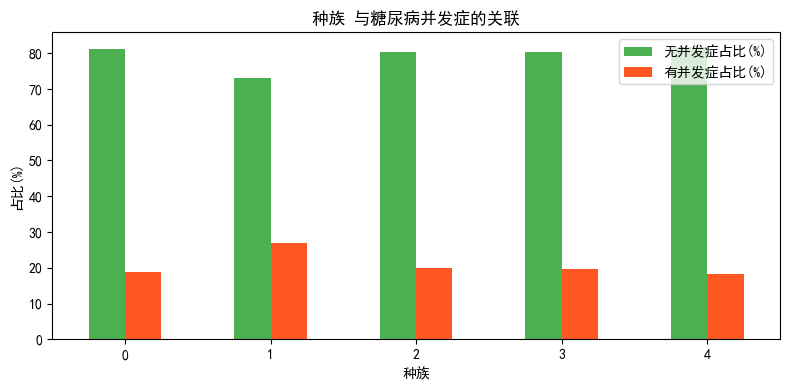


=== 性别 × has_complication 交叉表 ===
    无并发症占比(%)  有并发症占比(%)
性别                      
0       81.09      18.91
1       77.97      22.03


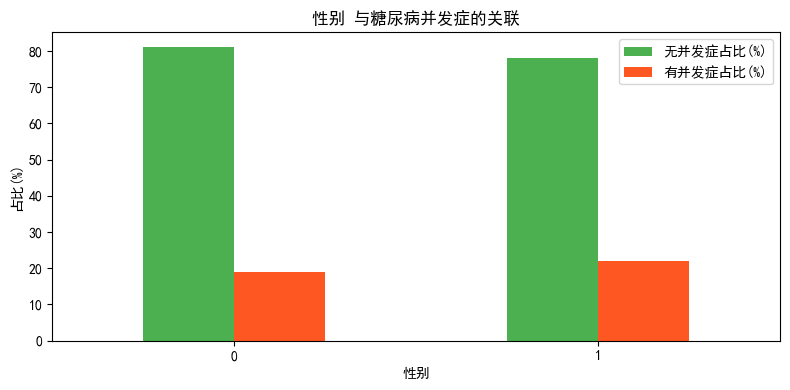


=== 年龄 × has_complication 交叉表 ===
    无并发症占比(%)  有并发症占比(%)
年龄                      
1       91.30       8.70
2       95.80       4.20
3       85.09      14.91
4       78.38      21.62
5       79.18      20.82
6       78.48      21.52
7       78.00      22.00
8       79.35      20.65
9       81.94      18.06
10      84.14      15.86


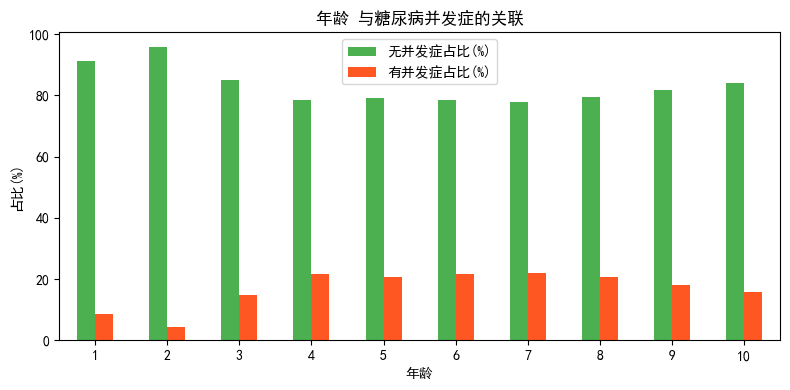


=== 再次入院情况 × has_complication 交叉表 ===
        无并发症占比(%)  有并发症占比(%)
再次入院情况                      
0           83.28      16.72
1           76.14      23.86
2           73.06      26.94


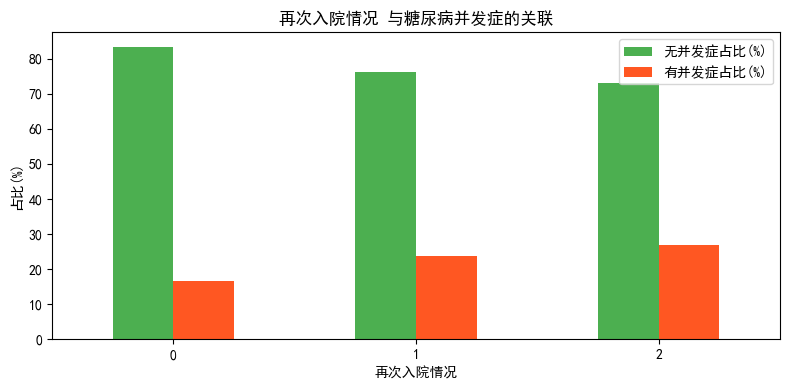

In [28]:
df['性别'] = df['性别'].replace(2, 0)  # 把2替换为0，也可以换成1
# 遍历所有分类变量，生成交叉表+条形图
cat_cols = ['种族', '性别', '年龄', '再次入院情况']
target_col = 'has_complication'

for col in cat_cols:
    print(f"\n=== {col} × {target_col} 交叉表 ===")
    # 生成交叉表（按行百分比）
    cross = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    cross = cross.round(2)
    cross.columns = ['无并发症占比(%)', '有并发症占比(%)']
    print(cross)
    
    # 画分组条形图，直观展示差异
    plt.figure(figsize=(8, 4))
    cross.plot(kind='bar', ax=plt.gca(), color=['#4CAF50', '#FF5722'])
    plt.title(f'{col} 与糖尿病并发症的关联')
    plt.ylabel('占比(%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()